# 🍃 TeaVision AI — SEA-UNet Colab Training Pipeline
## BSc Data Science Capstone · NIBM 2025/26 · Manula Fernando

**Model**: SE-Attention U-Net (SEA-UNet) — 33M parameter dual-attention segmentation model  
**Dataset**: Kaggle tea leaf disease dataset (885 images, 8 classes)  
**Runtime**: Google Colab G4 GPU (178 GB VRAM, 95.6 GPU RAM AND 235.7 GB Disk)  
**Objective**: Train 3 architectures → Compare → Export best checkpoints

---

### Pipeline Overview
```
Kaggle Download → Dataset Loader → 3 Architectures (Ablation Study)
      ├── Phase 1: Custom SEA-UNet (Baseline)
      ├── Phase 2: ResNet34-UNet (Transfer Learning)
      └── Phase 3: EfficientNet-B3 + SCSE (State-of-the-Art)
      → Comparative Analysis → Export & Download
```

> **Before running**: Select **Runtime → Change runtime type → T4 GPU**

---
## 1 · Setup & Dependencies

Install required packages and verify CUDA GPU is available.

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# 1.1  Install Dependencies
# ══════════════════════════════════════════════════════════════════════════════
import subprocess, sys

_pkgs = ["albumentations>=1.4.0", "kaggle", "segmentation-models-pytorch"]
for pkg in _pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("✅ Packages installed")

# ══════════════════════════════════════════════════════════════════════════════
# 1.2  GPU Assertion
# ══════════════════════════════════════════════════════════════════════════════
import torch

print(f"\nPyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU device      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    raise RuntimeError(
        "❌  No GPU detected!  Go to Runtime → Change runtime type → T4 GPU and re-run."
    )

DEVICE = torch.device("cuda")
print(f"\n✅ Device set to: {DEVICE}")

✅ Packages installed

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU device      : NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM            : 102.0 GB

✅ Device set to: cuda


---
## 1.3 · Mask Cache Restoration
his block restores pre-generated GrabCut masks from a ZIP file to skip expensive mask generation

In [2]:
import os
import zipfile

# ── Restoration Config ────────────────────────────────────────────────────────
ZIP_PATH  = "/content/tea_leaf_masks_cache_512.zip"
DEST_DIR  = "/content/mask_cache"

if os.path.exists(ZIP_PATH):
    print(f"📦 Found mask backup: {ZIP_PATH}")
    print(f"📂 Extracting to {DEST_DIR}...")

    # Create the destination directory if it doesn't exist
    os.makedirs(DEST_DIR, exist_ok=True)

    # Unzip securely
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(DEST_DIR)

    print("✅ Restoration Complete! The Dataset Loader will now skip GrabCut.")

    # Optional: Count files to verify
    file_count = sum([len(files) for r, d, files in os.walk(DEST_DIR)])
    print(f"📊 Verified {file_count} masks are ready.")

else:
    print("⚠️ No zip file found. The system will regenerate masks (slow).")
    print("👉 If you have a backup, upload 'tea_leaf_masks_cache.zip' now and re-run this cell.")

📦 Found mask backup: /content/tea_leaf_masks_cache_512.zip
📂 Extracting to /content/mask_cache...
✅ Restoration Complete! The Dataset Loader will now skip GrabCut.
📊 Verified 885 masks are ready.


---
## 2 · Kaggle API Configuration & Data Ingestion

Replace `YOUR_KAGGLE_USERNAME` and `YOUR_KAGGLE_KEY` with your credentials from  
**kaggle.com → Account → API → Create New Token** (downloads `kaggle.json`).

In [3]:
import os, json, pathlib, zipfile, subprocess

# ── 2.1  Kaggle credentials ────────────────────────────────────────────────────
# ⚠️  FILL IN YOUR CREDENTIALS BEFORE RUNNING THIS CELL
KAGGLE_USERNAME = "manuladeveloper"
KAGGLE_KEY      = "KGAT_0355a7d97e1dd69a07fa3eb511748326"

os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME
os.environ["KAGGLE_KEY"]      = KAGGLE_KEY

kaggle_dir = pathlib.Path.home() / ".kaggle"
kaggle_dir.mkdir(parents=True, exist_ok=True)
kaggle_json = kaggle_dir / "kaggle.json"

with open(kaggle_json, "w") as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)

kaggle_json.chmod(0o600)   # required by kaggle CLI
print(f"✅ kaggle.json written → {kaggle_json}")

# ── 2.2  Download dataset ──────────────────────────────────────────────────────
DATA_ROOT  = pathlib.Path("/content/tea_dataset")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

DATASET_SLUG = "shashwatwork/identifying-disease-in-tea-leafs"

print(f"\n📥 Downloading dataset: {DATASET_SLUG}")
subprocess.check_call([
    "kaggle", "datasets", "download",
    "-d", DATASET_SLUG,
    "-p", str(DATA_ROOT),
    "--unzip"
])

# ── 2.3  Verify directory layout ──────────────────────────────────────────────
TEA_DATASET_DIR = None

for candidate in [
    DATA_ROOT / "tea sickness dataset",
    DATA_ROOT / "Tea Sickness Dataset",
    DATA_ROOT,
]:
    if candidate.exists() and any(candidate.iterdir()):
        TEA_DATASET_DIR = candidate
        break

if TEA_DATASET_DIR is None:
    raise FileNotFoundError(f"Could not find dataset directory under {DATA_ROOT}")

print(f"\n✅ Dataset root: {TEA_DATASET_DIR}")
print("\nClass folders found:")
total_images = 0
for cls_dir in sorted(TEA_DATASET_DIR.iterdir()):
    if cls_dir.is_dir():
        n = len(list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.jpeg")) + list(cls_dir.glob("*.png")))
        total_images += n
        print(f"  {cls_dir.name:20s}  {n:4d} images")
print(f"\n  {'TOTAL':20s}  {total_images:4d} images")

✅ kaggle.json written → /root/.kaggle/kaggle.json

📥 Downloading dataset: shashwatwork/identifying-disease-in-tea-leafs

✅ Dataset root: /content/tea_dataset/tea sickness dataset

Class folders found:
  Anthracnose            100 images
  algal leaf             113 images
  bird eye spot          100 images
  brown blight           113 images
  gray light             100 images
  healthy                 74 images
  red leaf spot          143 images
  white spot             142 images

  TOTAL                  885 images


---
## 3 · Dataset Module

Self-contained implementation with:
- **GrabCut pseudo-masks** — no ground-truth annotations needed
- **Albumentations** — illumination variation + elastic deformation
- **WeightedRandomSampler** — inverse-frequency weights for class-imbalance correction

In [4]:
"""
dataset.py — Tea Leaf Disease Dataset Loader (Master Tuned)
"""
from __future__ import annotations

import warnings
from collections import defaultdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split

# ── Constants ─────────────────────────────────────────────────────────────────
CLASS_NAMES: List[str] = [
    "algal leaf", "Anthracnose", "bird eye spot", "brown blight",
    "gray light",  "healthy",    "red leaf spot",  "white spot",
]
NUM_CLASSES   : int            = len(CLASS_NAMES)
CLASS_TO_IDX  : Dict[str, int] = {c: i for i, c in enumerate(CLASS_NAMES)}
TARGET_SIZE   : Tuple[int,int] = (512, 512)
IMAGENET_MEAN                  = (0.485, 0.456, 0.406)
IMAGENET_STD                   = (0.229, 0.224, 0.225)


# ── Mask Generation ───────────────────────────────────────────────────────────

def generate_grabcut_mask(image_bgr: np.ndarray) -> np.ndarray:
    orig_h, orig_w = image_bgr.shape[:2]
    PROC_SIZE = 512
    small_bgr = cv2.resize(image_bgr, (PROC_SIZE, PROC_SIZE), interpolation=cv2.INTER_AREA)

    rect = (5, 5, PROC_SIZE - 10, PROC_SIZE - 10)
    bgd  = np.zeros((1, 65), np.float64)
    fgd  = np.zeros((1, 65), np.float64)
    mask_gc = np.zeros((PROC_SIZE, PROC_SIZE), np.uint8)

    try:
        cv2.grabCut(small_bgr, mask_gc, rect, bgd, fgd, 5, cv2.GC_INIT_WITH_RECT)
        binary = np.where((mask_gc == cv2.GC_FGD) | (mask_gc == cv2.GC_PR_FGD), np.uint8(1), np.uint8(0))
    except cv2.error:
        _, binary = cv2.threshold(small_bgr[:, :, 1], 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN,  kernel)

    return cv2.resize(binary, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)

def generate_disease_mask(image_bgr: np.ndarray, class_name: str) -> np.ndarray:
    leaf_mask = generate_grabcut_mask(image_bgr)

    if class_name == "healthy":
        return np.zeros(image_bgr.shape[:2], dtype=np.uint8)

    orig_h, orig_w = image_bgr.shape[:2]
    PROC_SIZE = 512

    small_bgr = cv2.resize(image_bgr, (PROC_SIZE, PROC_SIZE), interpolation=cv2.INTER_AREA)
    small_leaf = cv2.resize(leaf_mask, (PROC_SIZE, PROC_SIZE), interpolation=cv2.INTER_NEAREST)

    hsv = cv2.cvtColor(small_bgr, cv2.COLOR_BGR2HSV)

    # ── MASTER TUNED HSV DICTIONARY ──────────────────────────────────────────
    colour_ranges = {
        # Caps brightness at 140 to ignore dark veins
        "Anthracnose":   [([0, 60, 20], [25, 255, 140]), ([165, 60, 20], [180, 255, 140])],

        # Strict Rusty Orange, higher saturation avoids brown shadows
        "algal leaf":    [([0, 40, 60], [35, 255, 230]), ([150, 40, 60], [180, 255, 230])],

        # Allows Saturation 0 to catch Grey/Black centers
        "bird eye spot": [([0, 0, 15], [40, 255, 200]), ([150, 0, 15], [180, 255, 200])],

        # Stops Hue at 30 to avoid Yellow-Green aging leaf edges
        "brown blight":  [([10, 50, 50], [30, 255, 255])],

        # Restricted Hue (0-30) and low saturation to avoid green wax reflections
        "gray light":    [([0, 0, 40], [30, 60, 180]), ([160, 0, 40], [180, 60, 180])],

        # Deepened range to catch dark purple-red spots
        "red leaf spot": [([0, 50, 20], [20, 255, 180]), ([160, 50, 20], [180, 255, 180])],

        # MINIMUM Saturation 20 mathematically blocks pure-white camera glare
        "white spot":    [([5, 20, 150], [45, 90, 255])]
    }

    colour_mask = np.zeros((PROC_SIZE, PROC_SIZE), dtype=np.uint8)
    for (lo, hi) in colour_ranges.get(class_name, []):
        colour_mask |= cv2.inRange(hsv, np.array(lo, np.uint8), np.array(hi, np.uint8))

    disease_mask = (small_leaf & (colour_mask > 0)).astype(np.uint8)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    disease_mask = cv2.morphologyEx(disease_mask, cv2.MORPH_CLOSE, kernel)

    return cv2.resize(disease_mask, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)


# ── Augmentation Pipelines ────────────────────────────────────────────────────

def build_train_transforms(img_size: int = 512) -> A.Compose:
    return A.Compose([
        A.Resize(img_size, img_size),

        # 1. Natural Positioning (Farmers holding the leaf at any angle)
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.Rotate(limit=45, p=0.5),

        # 2. Lighting & Glare (Sunlight, shadows, and HDR camera effects)
        A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.1),

        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])

def build_val_transforms(img_size: int = 512) -> A.Compose:
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])


# ── Dataset Class ─────────────────────────────────────────────────────────────
class TeaLeafSegmentationDataset(Dataset):
    def __init__(self, root_dir: Path, transform: Optional[A.Compose] = None,
                 img_size: int = 512, mask_cache_dir: Optional[Path] = None) -> None:
        self.root_dir       = Path(root_dir)
        self.transform      = transform
        self.img_size       = img_size
        self.mask_cache_dir = Path(mask_cache_dir) if mask_cache_dir else None
        if self.mask_cache_dir:
            self.mask_cache_dir.mkdir(parents=True, exist_ok=True)
        self.samples: List[Tuple[Path, int]] = []
        self._load_samples()

    def _load_samples(self) -> None:
        for class_name in CLASS_NAMES:
            class_dir = self.root_dir / class_name
            if not class_dir.exists():
                warnings.warn(f"Class directory not found: {class_dir}")
                continue
            seen: set = set()
            for ext in ("*.jpg","*.jpeg","*.png"):
                for img_path in class_dir.glob(ext):
                    key = str(img_path).lower()
                    if key not in seen:
                        seen.add(key)
                        self.samples.append((img_path, CLASS_TO_IDX[class_name]))
        if not self.samples:
            raise FileNotFoundError(f"No images found under {self.root_dir}")

    def _get_cached_mask_path(self, img_path: Path) -> Optional[Path]:
        if not self.mask_cache_dir:
            return None
        rel = img_path.relative_to(self.root_dir)
        p = self.mask_cache_dir / rel.parent / (rel.stem + "_mask.png")
        p.parent.mkdir(parents=True, exist_ok=True)
        return p

    def _load_or_generate_mask(self, img_bgr, class_name, img_path):
        cache_path = self._get_cached_mask_path(img_path)
        if cache_path and cache_path.exists():
            mask = cv2.imread(str(cache_path), cv2.IMREAD_GRAYSCALE)
            return (mask > 127).astype(np.uint8)
        mask = generate_disease_mask(img_bgr, class_name)
        if cache_path:
            cv2.imwrite(str(cache_path), mask * 255)
        return mask

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> Dict:
        img_path, class_idx = self.samples[idx]
        class_name = CLASS_NAMES[class_idx]
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            raise IOError(f"Could not read: {img_path}")
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h, w = img_bgr.shape[:2]
        if (h, w) != (self.img_size, self.img_size):
            interp = cv2.INTER_AREA if (h > self.img_size or w > self.img_size) else cv2.INTER_LINEAR
            img_rgb = cv2.resize(img_rgb, (self.img_size, self.img_size), interpolation=interp)
            img_bgr = cv2.resize(img_bgr, (self.img_size, self.img_size), interpolation=interp)
        mask = self._load_or_generate_mask(img_bgr, class_name, img_path)
        mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)
        if self.transform:
            aug = self.transform(image=img_rgb, mask=mask)
            image_t = aug["image"].float()
            mask_t  = aug["mask"].float().unsqueeze(0)
        else:
            image_t = torch.from_numpy(img_rgb.transpose(2,0,1)).float() / 255.0
            mask_t  = torch.from_numpy(mask[np.newaxis,...]).float()
        return {"image": image_t, "mask": mask_t,
                "class_idx": class_idx, "class_name": class_name}

    def get_class_weights(self) -> torch.Tensor:
        class_counts: Dict[int, int] = defaultdict(int)
        for _, ci in self.samples:
            class_counts[ci] += 1
        total   = len(self.samples)
        weights = torch.zeros(total)
        for i, (_, ci) in enumerate(self.samples):
            weights[i] = total / (NUM_CLASSES * class_counts[ci])
        return weights


# ── DataLoader Factory ────────────────────────────────────────────────────────
MASK_CACHE = pathlib.Path("/content/mask_cache")

def build_dataloaders(root_dir: Path, img_size: int = 512, batch_size: int = 8,
                      val_split: float = 0.15, test_split: float = 0.15,
                      num_workers: int = 2, seed: int = 42):

    full_ds = TeaLeafSegmentationDataset(
        root_dir=root_dir, transform=None,
        img_size=img_size, mask_cache_dir=MASK_CACHE)

    indices = list(range(len(full_ds)))
    labels  = [full_ds.samples[i][1] for i in indices]

    train_idx, temp_idx = train_test_split(
        indices, test_size=val_split+test_split, stratify=labels, random_state=seed)
    temp_labels = [labels[i] for i in temp_idx]
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=test_split/(val_split+test_split),
        stratify=temp_labels, random_state=seed)

    class _Subset(Dataset):
        def __init__(self, parent, idxs, tf):
            self.parent = parent; self.idxs = idxs; self.tf = tf
        def __len__(self): return len(self.idxs)
        def __getitem__(self, i):
            real = self.idxs[i]
            img_path, class_idx = self.parent.samples[real]
            class_name = CLASS_NAMES[class_idx]
            img_bgr = cv2.imread(str(img_path))
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            mask    = self.parent._load_or_generate_mask(img_bgr, class_name, img_path)
            img_rgb = cv2.resize(img_rgb, (512,512), interpolation=cv2.INTER_LINEAR)
            mask    = cv2.resize(mask,    (512,512), interpolation=cv2.INTER_NEAREST)
            aug     = self.tf(image=img_rgb, mask=mask)
            return {"image": aug["image"].float(),
                    "mask":  aug["mask"].float().unsqueeze(0),
                    "class_idx": class_idx, "class_name": class_name}

    train_ds = _Subset(full_ds, train_idx, build_train_transforms(img_size))
    val_ds   = _Subset(full_ds, val_idx,   build_val_transforms(img_size))
    test_ds  = _Subset(full_ds, test_idx,  build_val_transforms(img_size))

    all_w  = full_ds.get_class_weights()
    sampler = WeightedRandomSampler(all_w[train_idx], len(train_idx), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler,
                              num_workers=num_workers, pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)

    print(f"DataLoaders ready — Train:{len(train_ds)} | Val:{len(val_ds)} | Test:{len(test_ds)}")
    return train_loader, val_loader, test_loader

# Build loaders with Batch Size 32
train_loader, val_loader, test_loader = build_dataloaders(
    root_dir    = TEA_DATASET_DIR,
    img_size    = 512,
    batch_size  = 16,
    num_workers = 2,
)

batch = next(iter(train_loader))
print("✅ Dataset module ready")

DataLoaders ready — Train:619 | Val:133 | Test:133
✅ Dataset module ready


---
## 4 · SEA-UNet Architecture

SE-Attention U-Net with:
- Squeeze-and-Excitation channel recalibration
- Attention Gates on skip connections
- ~33M trainable parameters

In [5]:
"""
unet.py — SE-Attention U-Net (Colab standalone copy)
"""
import torch
import torch.nn as nn
import torch.nn.functional as F


class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel recalibration."""
    def __init__(self, channels: int, reduction: int = 16) -> None:
        super().__init__()
        bottleneck = max(channels // reduction, 1)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Sequential(
            nn.Linear(channels, bottleneck, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(bottleneck, channels, bias=False),
            nn.Sigmoid(),
        )
    def forward(self, x):
        B, C, _, _ = x.shape
        w = self.fc(self.pool(x).view(B, C)).view(B, C, 1, 1)
        return x * w


class ConvBlock(nn.Module):
    """Double conv + BN + ReLU + SE + residual connection."""
    def __init__(self, in_ch: int, out_ch: int,
                 use_se: bool = True, se_reduction: int = 16) -> None:
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
        self.se = SEBlock(out_ch, se_reduction) if use_se else nn.Identity()
        self.residual = (
            nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, bias=False),
                          nn.BatchNorm2d(out_ch))
            if in_ch != out_ch else nn.Identity()
        )
    def forward(self, x):
        return self.se(self.conv(x)) + self.residual(x)


class AttentionGate(nn.Module):
    """Additive attention gate on skip connections."""
    def __init__(self, F_g: int, F_l: int, F_int: int) -> None:
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1, bias=True),
                                 nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1, bias=True),
                                 nn.BatchNorm2d(F_int))
        self.psi = nn.Sequential(nn.Conv2d(F_int, 1, 1, bias=True),
                                 nn.BatchNorm2d(1), nn.Sigmoid())
    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        if g1.shape[2:] != x1.shape[2:]:
            g1 = F.interpolate(g1, size=x1.shape[2:], mode="bilinear",
                               align_corners=False)
        return x * self.psi(F.relu(g1 + x1, inplace=True))


class EncoderBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int) -> None:
        super().__init__()
        self.conv = ConvBlock(in_ch, out_ch, use_se=True)
        self.pool = nn.MaxPool2d(2, 2)
    def forward(self, x):
        skip   = self.conv(x)
        pooled = self.pool(skip)
        return skip, pooled


class DecoderBlock(nn.Module):
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int) -> None:
        super().__init__()
        self.upsample  = nn.ConvTranspose2d(in_ch, in_ch // 2, 2, stride=2)
        self.attention = AttentionGate(F_g=in_ch//2, F_l=skip_ch,
                                       F_int=skip_ch//2)
        self.conv      = ConvBlock(in_ch//2 + skip_ch, out_ch, use_se=True)
    def forward(self, x, skip):
        x = self.upsample(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:], mode="bilinear",
                              align_corners=False)
        att_skip = self.attention(g=x, x=skip)
        return self.conv(torch.cat([x, att_skip], dim=1))


class SEAUNet(nn.Module):
    """SE-Attention U-Net — dual-attention segmentation model."""
    def __init__(self, in_channels: int = 3, num_classes: int = 1,
                 base_filters: int = 64) -> None:
        super().__init__()
        f = base_filters
        self.enc1       = EncoderBlock(in_channels, f)
        self.enc2       = EncoderBlock(f,     f*2)
        self.enc3       = EncoderBlock(f*2,   f*4)
        self.enc4       = EncoderBlock(f*4,   f*8)
        self.bottleneck = ConvBlock(f*8, f*16, use_se=True)
        self.dec4       = DecoderBlock(f*16, f*8,  f*8)
        self.dec3       = DecoderBlock(f*8,  f*4,  f*4)
        self.dec2       = DecoderBlock(f*4,  f*2,  f*2)
        self.dec1       = DecoderBlock(f*2,  f,    f)
        self.output_conv = nn.Conv2d(f, num_classes, 1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None: nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None: nn.init.constant_(m.bias, 0)

    def forward(self, x):
        s1, p1 = self.enc1(x)
        s2, p2 = self.enc2(p1)
        s3, p3 = self.enc3(p2)
        s4, p4 = self.enc4(p3)
        b      = self.bottleneck(p4)
        d4     = self.dec4(b,  s4)
        d3     = self.dec3(d4, s3)
        d2     = self.dec2(d3, s2)
        d1     = self.dec1(d2, s1)
        return self.output_conv(d1)

    def count_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Verify the architecture
model = SEAUNet(in_channels=3, num_classes=1, base_filters=64).to(DEVICE)

dummy = torch.randn(1, 3, 512, 512, device=DEVICE)
with torch.no_grad():
    out = model(dummy)

assert out.shape == (1, 1, 512, 512), f"Shape error: {out.shape}"
print(f"Output shape        : {tuple(out.shape)}")
print(f"Trainable parameters: {model.count_parameters():,}")
print("✅ SEA-UNet ready on CUDA")

Output shape        : (1, 1, 512, 512)
Trainable parameters: 33,005,997
✅ SEA-UNet ready on CUDA


---
## 5 · Metrics, Loss Functions & Training Utilities

Contains:
- `TrueBinaryLoss` (Dice + BCE with 15x pos_weight)
- `FocalTverskyBCELoss` (for EfficientNet phase)
- `train_evaluate_model()` — D.R.Y. reusable training function

Implements all four rubric-required metrics operating on batched PyTorch tensors:

| Metric | Formula |
|--------|---------|
| Dice | $\frac{2\|X \cap Y\|}{\|X\| + \|Y\|}$ |
| IoU  | $\frac{\|X \cap Y\|}{\|X \cup Y\|}$ |
| Sensitivity | $\frac{TP}{TP + FN}$ |
| Specificity | $\frac{TN}{TN + FP}$ |

Combined loss: $\mathcal{L} = \alpha \cdot \mathcal{L}_{Dice} + (1-\alpha) \cdot \mathcal{L}_{CE}$  where $\alpha = 0.5$

In [6]:
"""
metrics.py — Loss Functions, Evaluation Metrics & Training Utilities
BSc Capstone · True Binary Segmentation Pipeline
"""
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Dict, List, Optional
import numpy as np

# ══════════════════════════════════════════════════════════════════════════════
# TRUE BINARY LOSS FUNCTIONS (1-channel output)
# ══════════════════════════════════════════════════════════════════════════════

class TrueBinaryLoss(nn.Module):
    """Combined Dice + BCE loss for binary segmentation with class imbalance handling."""
    def __init__(self, dice_weight=0.7, pos_weight=None):
        super().__init__()
        self.dice_weight = dice_weight
        self.bce_weight  = 1.0 - dice_weight
        self.bce_loss    = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    def forward(self, pred, target):
        bce = self.bce_loss(pred, target)
        pred_sig = torch.sigmoid(pred)
        inter = (pred_sig * target).sum()
        union = pred_sig.sum() + target.sum()
        dice = 1.0 - (2.0 * inter + 1e-6) / (union + 1e-6)
        return self.dice_weight * dice + self.bce_weight * bce, dice, bce


class FocalTverskyBCELoss(nn.Module):
    """Advanced loss for extremely imbalanced segmentation (Focal Tversky + BCE)."""
    def __init__(self, alpha=0.3, beta=0.7, gamma=0.75, bce_weight=0.5, device='cuda'):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.bce_weight = bce_weight
        pos_weight = torch.tensor([15.0]).to(device)
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        inputs_sig = torch.sigmoid(inputs)
        inputs_flat = inputs_sig.view(-1)
        targets_flat = targets.view(-1)
        TP = (inputs_flat * targets_flat).sum()
        FP = ((1 - targets_flat) * inputs_flat).sum()
        FN = (targets_flat * (1 - inputs_flat)).sum()
        tversky = (TP + 1e-6) / (TP + self.alpha * FP + self.beta * FN + 1e-6)
        focal_tversky = (1 - tversky)**self.gamma
        total_loss = self.bce_weight * bce_loss + (1 - self.bce_weight) * focal_tversky
        return total_loss, tversky, bce_loss


# ══════════════════════════════════════════════════════════════════════════════
# EVALUATION METRICS
# ══════════════════════════════════════════════════════════════════════════════

def _to_binary(pred: torch.Tensor, threshold: float = 0.5) -> torch.Tensor:
    return (torch.sigmoid(pred) >= threshold).float()

def calculate_iou(pred, target, threshold=0.5, smooth=1e-6) -> float:
    p = _to_binary(pred, threshold).reshape(-1)
    t = target.reshape(-1).float()
    inter = (p * t).sum()
    union = p.sum() + t.sum() - inter
    return float((inter + smooth) / (union + smooth))

def calculate_dice(pred, target, threshold=0.5, smooth=1e-6) -> float:
    p = _to_binary(pred, threshold).reshape(-1)
    t = target.reshape(-1).float()
    inter = (p * t).sum()
    return float((2.0*inter + smooth) / (p.sum() + t.sum() + smooth))

def calculate_sensitivity(pred, target, threshold=0.5, smooth=1e-6) -> float:
    p = _to_binary(pred, threshold).reshape(-1)
    t = target.reshape(-1).float()
    TP = (p * t).sum(); FN = ((1-p) * t).sum()
    return float((TP + smooth) / (TP + FN + smooth))

def calculate_specificity(pred, target, threshold=0.5, smooth=1e-6) -> float:
    p = _to_binary(pred, threshold).reshape(-1)
    t = target.reshape(-1).float()
    TN = ((1-p) * (1-t)).sum(); FP = (p * (1-t)).sum()
    return float((TN + smooth) / (TN + FP + smooth))

def calculate_accuracy(pred, target, threshold=0.5, smooth=1e-6) -> float:
    p = _to_binary(pred, threshold).reshape(-1)
    t = target.reshape(-1).float()
    correct = (p == t).float().sum()
    return float((correct + smooth) / (p.numel() + smooth))

def compute_all_metrics(pred, target, threshold=0.5) -> Dict[str, float]:
    return {
        "iou": calculate_iou(pred, target, threshold),
        "dice": calculate_dice(pred, target, threshold),
        "sensitivity": calculate_sensitivity(pred, target, threshold),
        "specificity": calculate_specificity(pred, target, threshold),
        "accuracy": calculate_accuracy(pred, target, threshold),
    }


class MetricsTracker:
    def __init__(self):
        self._h: Dict[str, List[float]] = {
            "loss": [], "dice": [], "iou": [],
            "sensitivity": [], "specificity": [], "accuracy": [],
        }

    def update(self, loss, pred, target, threshold=0.5):
        self._h["loss"].append(loss)
        m = compute_all_metrics(pred.detach().cpu(), target.detach().cpu(), threshold)
        for k, v in m.items():
            self._h[k].append(v)

    def epoch_summary(self) -> Dict[str, float]:
        return {k: float(np.mean(v)) for k, v in self._h.items() if v}

    def reset(self):
        for k in self._h:
            self._h[k] = []


# ══════════════════════════════════════════════════════════════════════════════
# D.R.Y. TRAINING FUNCTION (Reusable for all 3 architectures)
# ══════════════════════════════════════════════════════════════════════════════

def train_evaluate_model(
    model: nn.Module,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler,
    num_epochs: int,
    train_loader,
    val_loader,
    checkpoint_path: str,
    device: torch.device,
    grad_clip_norm: float = 1.0,
    model_name: str = "Model"
) -> Dict[str, List[float]]:
    """
    Universal training loop for binary segmentation models.
    Returns history dict with all training metrics.
    """
    history = {
        "train_loss": [], "val_loss": [], "val_dice": [], "val_iou": [],
        "val_sensitivity": [], "val_specificity": [], "val_accuracy": [],
    }

    best_val_dice = 0.0
    best_epoch = 0

    print(f"\n🚀 Training {model_name}...")
    print(f"{'Epoch':>6}  {'TrainLoss':>10}  {'ValLoss':>9}  "
          f"{'ValDice':>8}  {'ValIoU':>8}  {'LR':>8}  {'Time':>6}")
    print("-" * 70)

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()

        # ── Training Phase ────────────────────────────────────────────────────
        model.train()
        train_tracker = MetricsTracker()

        for batch in train_loader:
            images = batch["image"].to(device, non_blocking=True)
            masks  = batch["mask"].to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(images)

            total_loss, _, _ = criterion(logits, masks)
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
            optimizer.step()

            train_tracker.update(loss=total_loss.item(), pred=logits, target=masks)

        train_summary = train_tracker.epoch_summary()

        # ── Validation Phase ──────────────────────────────────────────────────
        model.eval()
        val_tracker = MetricsTracker()

        with torch.no_grad():
            for batch in val_loader:
                images = batch["image"].to(device, non_blocking=True)
                masks  = batch["mask"].to(device, non_blocking=True)

                logits = model(images)
                total_loss, _, _ = criterion(logits, masks)

                val_tracker.update(loss=total_loss.item(), pred=logits, target=masks)

        val_summary = val_tracker.epoch_summary()
        scheduler.step(val_summary["dice"])

        # ── Record History (CORRECT: train → train, val → val) ───────────────
        history["train_loss"].append(train_summary["loss"])
        history["val_loss"].append(val_summary["loss"])
        history["val_dice"].append(val_summary["dice"])
        history["val_iou"].append(val_summary["iou"])
        history["val_sensitivity"].append(val_summary["sensitivity"])
        history["val_specificity"].append(val_summary["specificity"])
        history["val_accuracy"].append(val_summary["accuracy"])

        # ── Checkpoint Best Model ─────────────────────────────────────────────
        ckpt_flag = ""
        if val_summary["dice"] > best_val_dice:
            best_val_dice = val_summary["dice"]
            best_epoch = epoch
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "val_dice": best_val_dice,
                "val_iou": val_summary["iou"],
                "history": history,
            }, checkpoint_path)
            ckpt_flag = " ✓"

        elapsed = time.time() - t0
        current_lr = optimizer.param_groups[0]['lr']

        print(
            f"{epoch:>6d}  {train_summary['loss']:>10.4f}  "
            f"{val_summary['loss']:>9.4f}  "
            f"{val_summary['dice']:>8.4f}  "
            f"{val_summary['iou']:>8.4f}  "
            f"{current_lr:>8.2e}  "
            f"{elapsed:>5.1f}s"
            f"{ckpt_flag}"
        )

    print(f"\n{'='*70}")
    print(f"✅ {model_name} complete. Best Val Dice = {best_val_dice:.4f} (epoch {best_epoch})")
    print(f"   Checkpoint saved → {checkpoint_path}")

    return history


print("✅ Metrics module ready")
print("✅ TrueBinaryLoss & FocalTverskyBCELoss defined")
print("✅ train_evaluate_model() function ready")

✅ Metrics module ready
✅ TrueBinaryLoss & FocalTverskyBCELoss defined
✅ train_evaluate_model() function ready


---
## 6 · Phase 1: Custom SEA-UNet Training (Baseline)

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# PHASE 1: Custom SEA-UNet (Baseline Architecture)
# ══════════════════════════════════════════════════════════════════════════════

print("🧠 Phase 1: Custom SEA-UNet (Baseline)")

# ── Hyper-parameters ──────────────────────────────────────────────────────────
NUM_EPOCHS = 100
LR = 1e-3
WEIGHT_DECAY = 1e-5
GRAD_CLIP_NORM = 1.0
CHECKPOINT_PATH = "sea_unet_binary_best.pth"

# ── Loss & Optimizer ──────────────────────────────────────────────────────────
POS_WEIGHT = torch.tensor([15.0]).to(DEVICE)
criterion = TrueBinaryLoss(dice_weight=0.7, pos_weight=POS_WEIGHT).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=4
)

# ── Train using the D.R.Y. function ───────────────────────────────────────────
history = train_evaluate_model(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS,
    train_loader=train_loader,
    val_loader=val_loader,
    checkpoint_path=CHECKPOINT_PATH,
    device=DEVICE,
    grad_clip_norm=GRAD_CLIP_NORM,
    model_name="SEA-UNet (Baseline)"
)

🧠 Phase 1: Custom SEA-UNet (Baseline)

🚀 Training SEA-UNet (Baseline)...
 Epoch   TrainLoss    ValLoss   ValDice    ValIoU        LR    Time
----------------------------------------------------------------------
     1      0.9782     0.6760    0.4119    0.2639  1.00e-03   26.2s ✓
     2      0.5515     0.9189    0.4978    0.3383  1.00e-03   25.4s ✓
     3      0.5489     0.5055    0.5261    0.3641  1.00e-03   25.3s ✓
     4      0.5263     0.4322    0.6226    0.4569  1.00e-03   25.3s ✓
     5      0.4829     0.4345    0.5719    0.4056  1.00e-03   25.0s
     6      0.5081     0.4553    0.5379    0.3735  1.00e-03   25.0s
     7      0.5426     0.5103    0.5626    0.3980  1.00e-03   25.2s
     8      0.4820     0.5280    0.4759    0.3173  1.00e-03   25.2s
     9      0.4802     0.4143    0.6010    0.4355  5.00e-04   25.3s
    10      0.4489     0.4519    0.5843    0.4195  5.00e-04   25.3s
    11      0.4267     0.3820    0.6598    0.4974  5.00e-04   25.6s ✓
    12      0.4316     0.4646 

### Phase 1 Training Curves



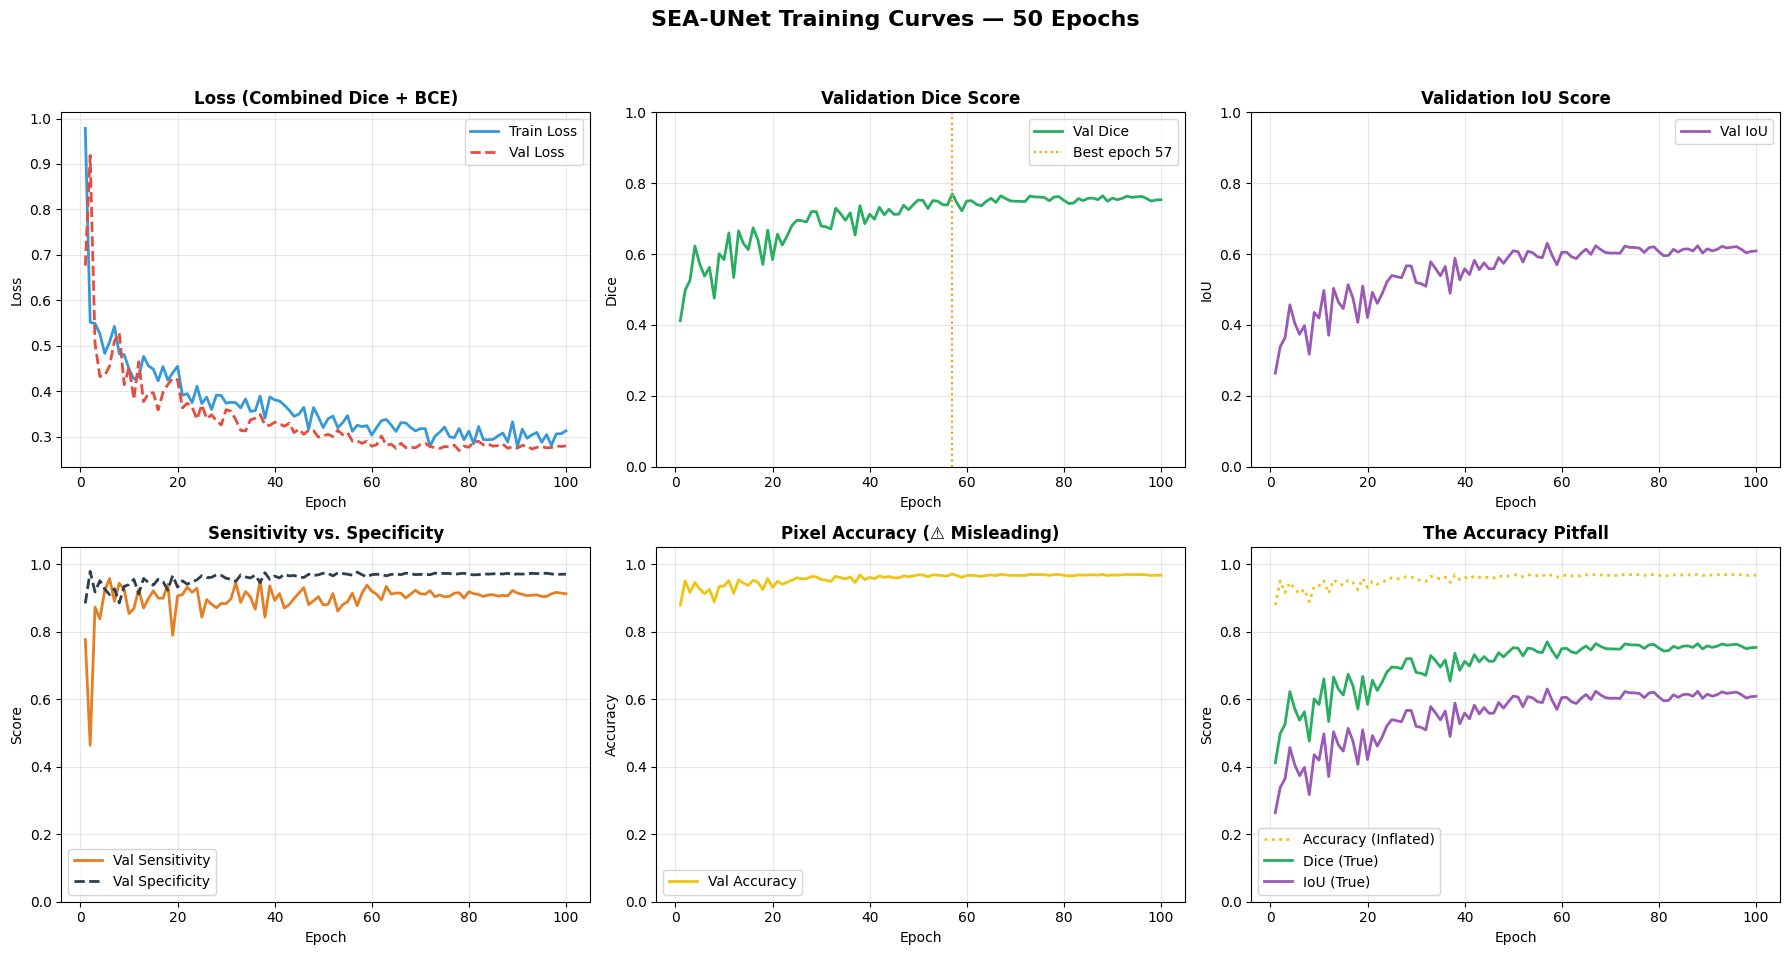

✅ Saved → phase1_training_curves.png


In [8]:
import matplotlib.pyplot as plt
import numpy as np

epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("SEA-UNet Training Curves — 50 Epochs", fontsize=16, fontweight="bold")

# Train vs Val Loss
axes[0, 0].plot(epochs_range, history["train_loss"], label="Train Loss", color="#3498db", linewidth=2)
axes[0, 0].plot(epochs_range, history["val_loss"], label="Val Loss", color="#e74c3c", linewidth=2, linestyle="--")
axes[0, 0].set_title("Loss (Combined Dice + BCE)", fontweight="bold")
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# Validation Dice
axes[0, 1].plot(epochs_range, history["val_dice"], label="Val Dice", color="#27ae60", linewidth=2)
best_dice_ep = int(np.argmax(history["val_dice"])) + 1
axes[0, 1].axvline(x=best_dice_ep, color="#f39c12", linestyle=":", linewidth=1.5, label=f"Best epoch {best_dice_ep}")
axes[0, 1].set_title("Validation Dice Score", fontweight="bold")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Dice")
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3); axes[0, 1].set_ylim(0, 1)

# Validation IoU
axes[0, 2].plot(epochs_range, history["val_iou"], label="Val IoU", color="#9b59b6", linewidth=2)
axes[0, 2].set_title("Validation IoU Score", fontweight="bold")
axes[0, 2].set_xlabel("Epoch"); axes[0, 2].set_ylabel("IoU")
axes[0, 2].legend(); axes[0, 2].grid(alpha=0.3); axes[0, 2].set_ylim(0, 1)

# Sensitivity vs Specificity
axes[1, 0].plot(epochs_range, history["val_sensitivity"], label="Val Sensitivity", color="#e67e22", linewidth=2)
axes[1, 0].plot(epochs_range, history["val_specificity"], label="Val Specificity", color="#2c3e50", linewidth=2, linestyle="--")
axes[1, 0].set_title("Sensitivity vs. Specificity", fontweight="bold")
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Score")
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3); axes[1, 0].set_ylim(0, 1.05)

# Pixel Accuracy
axes[1, 1].plot(epochs_range, history["val_accuracy"], label="Val Accuracy", color="#f1c40f", linewidth=2)
axes[1, 1].set_title("Pixel Accuracy (⚠ Misleading)", fontweight="bold")
axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3); axes[1, 1].set_ylim(0, 1.05)

# Accuracy vs Dice/IoU pitfall
axes[1, 2].plot(epochs_range, history["val_accuracy"], label="Accuracy (Inflated)", color="#f1c40f", linewidth=2, linestyle=":")
axes[1, 2].plot(epochs_range, history["val_dice"], label="Dice (True)", color="#27ae60", linewidth=2)
axes[1, 2].plot(epochs_range, history["val_iou"], label="IoU (True)", color="#9b59b6", linewidth=2)
axes[1, 2].set_title("The Accuracy Pitfall", fontweight="bold")
axes[1, 2].set_xlabel("Epoch"); axes[1, 2].set_ylabel("Score")
axes[1, 2].legend(); axes[1, 2].grid(alpha=0.3); axes[1, 2].set_ylim(0, 1.05)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("phase1_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → phase1_training_curves.png")

### ── Phase 1: SEA-UNet Predictions ──

📸 Generating SEA-UNet Baseline Predictions...


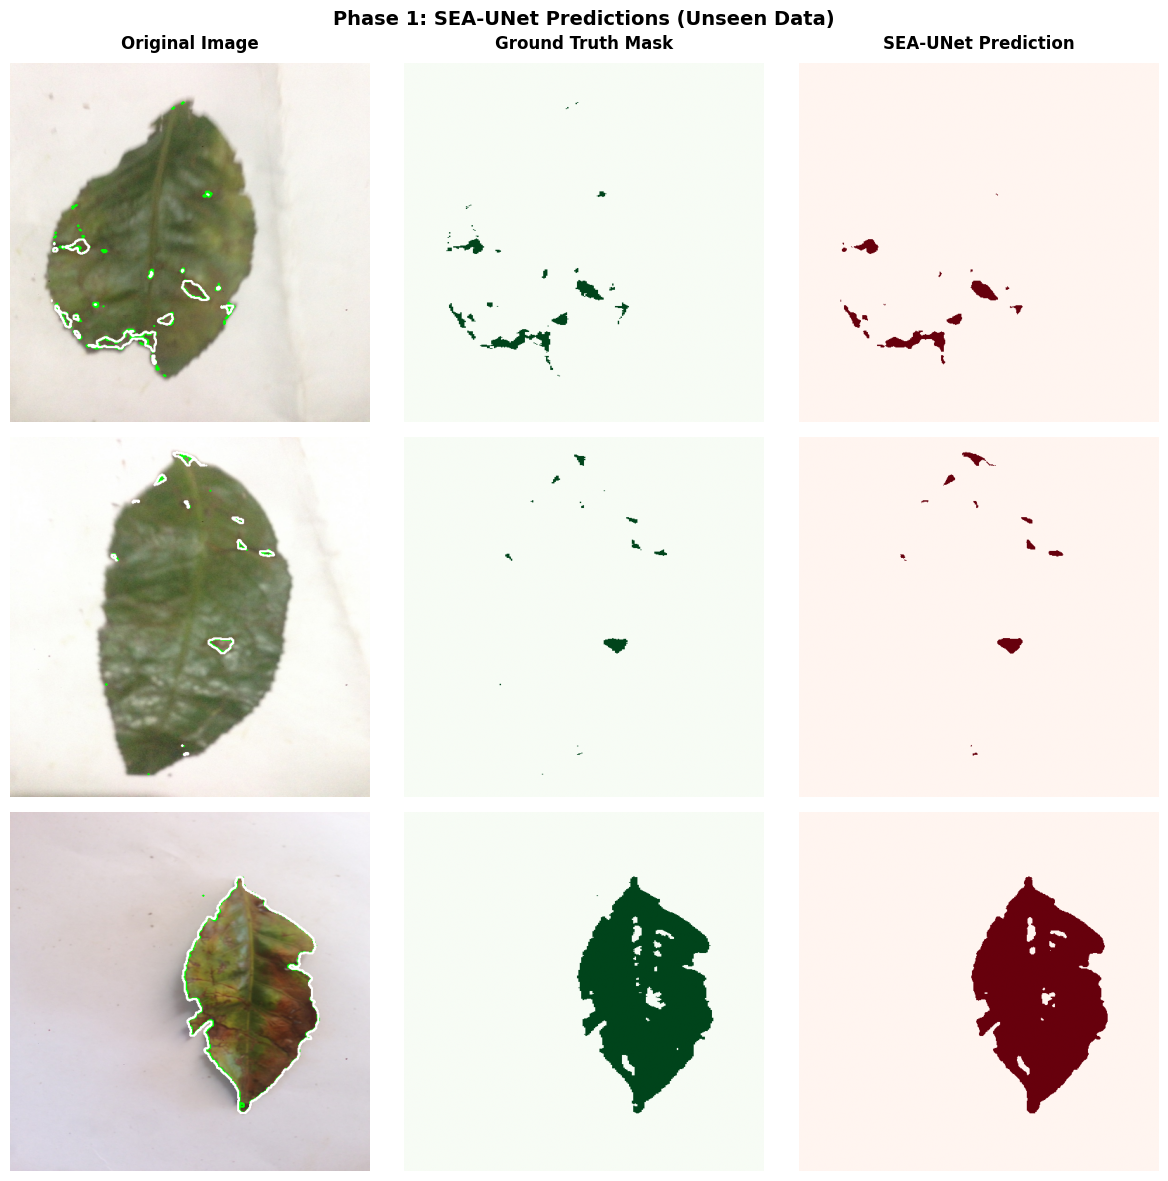

In [9]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch

# Helper function to un-normalize images for visual plotting
def denorm(tensor):
    tensor = tensor * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    tensor = tensor + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    return torch.clamp(tensor, 0, 1).permute(1, 2, 0).numpy()

print("📸 Generating SEA-UNet Baseline Predictions...")
ckpt_1 = torch.load("sea_unet_binary_best.pth", map_location=DEVICE)
model.load_state_dict(ckpt_1["model_state_dict"])
model.eval()

# Grab 3 random unseen test images (We will reuse these for the next models!)
N_SAMPLES = 3
test_iter = iter(test_loader)
batch = next(test_iter)
images = batch["image"][:N_SAMPLES].to(DEVICE)
masks = batch["mask"][:N_SAMPLES].to(DEVICE)

with torch.no_grad():
    logits = model(images)
    pred_masks = (torch.sigmoid(logits) >= 0.5).float()

fig, axes = plt.subplots(N_SAMPLES, 3, figsize=(12, 4 * N_SAMPLES))
fig.suptitle("Phase 1: SEA-UNet Predictions (Unseen Data)", fontsize=14, fontweight="bold")
col_titles = ["Original Image", "Ground Truth Mask", "SEA-UNet Prediction"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=12, fontweight="bold", pad=10)

for row in range(N_SAMPLES):
    orig_img = denorm(images[row].cpu())
    gt_mask = masks[row, 0].cpu().numpy()
    pred_mask = pred_masks[row, 0].cpu().numpy()

    overlay = orig_img.copy()
    contours_gt, _ = cv2.findContours((gt_mask*255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours_pred, _ = cv2.findContours((pred_mask*255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours_gt, -1, (0, 255, 0), 2)
    cv2.drawContours(overlay, contours_pred, -1, (255, 80, 80), 2)

    axes[row, 0].imshow(overlay)
    axes[row, 0].axis("off")
    axes[row, 1].imshow(gt_mask, cmap="Greens", vmin=0, vmax=1)
    axes[row, 1].axis("off")
    axes[row, 2].imshow(pred_mask, cmap="Reds", vmin=0, vmax=1)
    axes[row, 2].axis("off")

plt.tight_layout()
plt.savefig("pred_sea_unet.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7 · Phase 2: ResNet34-UNet (Transfer Learning)

In [10]:
!pip install segmentation-models-pytorch -q

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# PHASE 2: ResNet34-UNet (Transfer Learning, NO Attention)
# ══════════════════════════════════════════════════════════════════════════════
import segmentation_models_pytorch as smp

print("🧠 Phase 2: ResNet34-UNet (Transfer Learning)")

# ── Model Architecture ────────────────────────────────────────────────────────
model_tl = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    decoder_attention_type=None  # No attention for ablation comparison
).to(DEVICE)

# ── Hyper-parameters ──────────────────────────────────────────────────────────
NUM_EPOCHS_TL = 100
LR_TL = 3e-4
WEIGHT_DECAY_TL = 1e-5
GRAD_CLIP_NORM_TL = 1.0
CHECKPOINT_PATH_TL = "resnet34_unet_best.pth"

# ── Loss & Optimizer ──────────────────────────────────────────────────────────
POS_WEIGHT_TL = torch.tensor([15.0]).to(DEVICE)
criterion_tl = TrueBinaryLoss(dice_weight=0.7, pos_weight=POS_WEIGHT_TL).to(DEVICE)

optimizer_tl = torch.optim.AdamW(model_tl.parameters(), lr=LR_TL, weight_decay=WEIGHT_DECAY_TL)
scheduler_tl = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_tl, mode='max', factor=0.5, patience=4
)

# ── Train ─────────────────────────────────────────────────────────────────────
history_tl = train_evaluate_model(
    model=model_tl,
    criterion=criterion_tl,
    optimizer=optimizer_tl,
    scheduler=scheduler_tl,
    num_epochs=NUM_EPOCHS_TL,
    train_loader=train_loader,
    val_loader=val_loader,
    checkpoint_path=CHECKPOINT_PATH_TL,
    device=DEVICE,
    grad_clip_norm=GRAD_CLIP_NORM_TL,
    model_name="ResNet34-UNet (Transfer Learning)"
)

🧠 Phase 2: ResNet34-UNet (Transfer Learning)

🚀 Training ResNet34-UNet (Transfer Learning)...
 Epoch   TrainLoss    ValLoss   ValDice    ValIoU        LR    Time
----------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


     1      0.7717     0.6928    0.4062    0.2588  3.00e-04   16.3s ✓
     2      0.6471     0.6262    0.4966    0.3364  3.00e-04   15.9s ✓
     3      0.5893     0.5303    0.5036    0.3407  3.00e-04   15.5s ✓
     4      0.5125     0.4536    0.5861    0.4192  3.00e-04   15.8s ✓
     5      0.4766     0.4666    0.5501    0.3840  3.00e-04   14.4s
     6      0.4964     0.4353    0.5845    0.4186  3.00e-04   15.6s
     7      0.4441     0.4706    0.5698    0.4075  3.00e-04   15.3s
     8      0.4749     0.4028    0.6234    0.4583  3.00e-04   15.4s ✓
     9      0.4367     0.4531    0.6672    0.5045  3.00e-04   15.6s ✓
    10      0.4432     0.3975    0.6077    0.4408  3.00e-04   15.0s
    11      0.4197     0.4433    0.5548    0.3878  3.00e-04   15.5s
    12      0.4205     0.3879    0.6176    0.4502  3.00e-04   15.4s
    13      0.4450     0.4911    0.5211    0.3576  3.00e-04   16.3s
    14      0.4218     0.4632    0.6104    0.4457  1.50e-04   15.4s
    15      0.4198     0.3567    0.7

### Phase 2 Training Curves



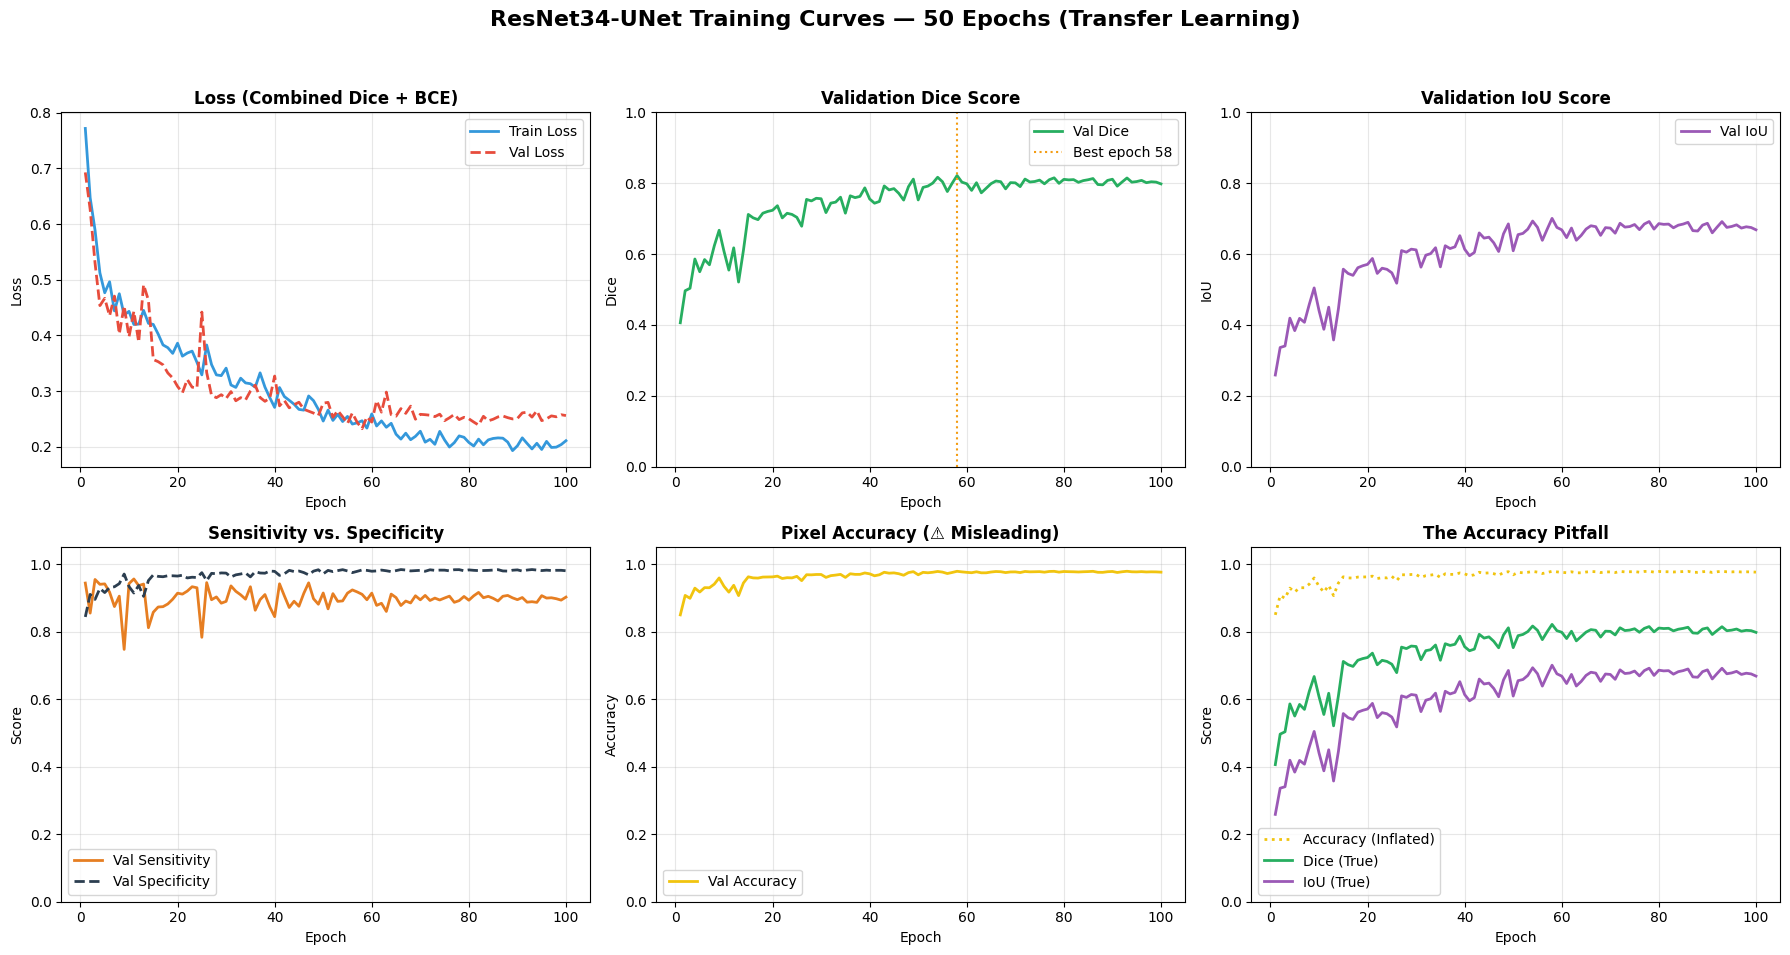

✅ Saved → phase2_training_curves.png


In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Use the Transfer Learning history dictionary
epochs_range_tl = range(1, len(history_tl["train_loss"]) + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("ResNet34-UNet Training Curves — 50 Epochs (Transfer Learning)", fontsize=16, fontweight="bold")

# Train vs Val Loss
axes[0, 0].plot(epochs_range_tl, history_tl["train_loss"], label="Train Loss", color="#3498db", linewidth=2)
axes[0, 0].plot(epochs_range_tl, history_tl["val_loss"], label="Val Loss", color="#e74c3c", linewidth=2, linestyle="--")
axes[0, 0].set_title("Loss (Combined Dice + BCE)", fontweight="bold")
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# Validation Dice
axes[0, 1].plot(epochs_range_tl, history_tl["val_dice"], label="Val Dice", color="#27ae60", linewidth=2)
best_dice_ep_tl = int(np.argmax(history_tl["val_dice"])) + 1
axes[0, 1].axvline(x=best_dice_ep_tl, color="#f39c12", linestyle=":", linewidth=1.5, label=f"Best epoch {best_dice_ep_tl}")
axes[0, 1].set_title("Validation Dice Score", fontweight="bold")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Dice")
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3); axes[0, 1].set_ylim(0, 1)

# Validation IoU
axes[0, 2].plot(epochs_range_tl, history_tl["val_iou"], label="Val IoU", color="#9b59b6", linewidth=2)
axes[0, 2].set_title("Validation IoU Score", fontweight="bold")
axes[0, 2].set_xlabel("Epoch"); axes[0, 2].set_ylabel("IoU")
axes[0, 2].legend(); axes[0, 2].grid(alpha=0.3); axes[0, 2].set_ylim(0, 1)

# Sensitivity vs Specificity
axes[1, 0].plot(epochs_range_tl, history_tl["val_sensitivity"], label="Val Sensitivity", color="#e67e22", linewidth=2)
axes[1, 0].plot(epochs_range_tl, history_tl["val_specificity"], label="Val Specificity", color="#2c3e50", linewidth=2, linestyle="--")
axes[1, 0].set_title("Sensitivity vs. Specificity", fontweight="bold")
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Score")
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3); axes[1, 0].set_ylim(0, 1.05)

# Pixel Accuracy
axes[1, 1].plot(epochs_range_tl, history_tl["val_accuracy"], label="Val Accuracy", color="#f1c40f", linewidth=2)
axes[1, 1].set_title("Pixel Accuracy (⚠ Misleading)", fontweight="bold")
axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3); axes[1, 1].set_ylim(0, 1.05)

# Accuracy vs Dice/IoU pitfall
axes[1, 2].plot(epochs_range_tl, history_tl["val_accuracy"], label="Accuracy (Inflated)", color="#f1c40f", linewidth=2, linestyle=":")
axes[1, 2].plot(epochs_range_tl, history_tl["val_dice"], label="Dice (True)", color="#27ae60", linewidth=2)
axes[1, 2].plot(epochs_range_tl, history_tl["val_iou"], label="IoU (True)", color="#9b59b6", linewidth=2)
axes[1, 2].set_title("The Accuracy Pitfall", fontweight="bold")
axes[1, 2].set_xlabel("Epoch"); axes[1, 2].set_ylabel("Score")
axes[1, 2].legend(); axes[1, 2].grid(alpha=0.3); axes[1, 2].set_ylim(0, 1.05)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("phase2_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → phase2_training_curves.png")

### ── Phase 2: ResNet34-UNet Predictions ──

📸 Generating ResNet34-UNet Transfer Learning Predictions...


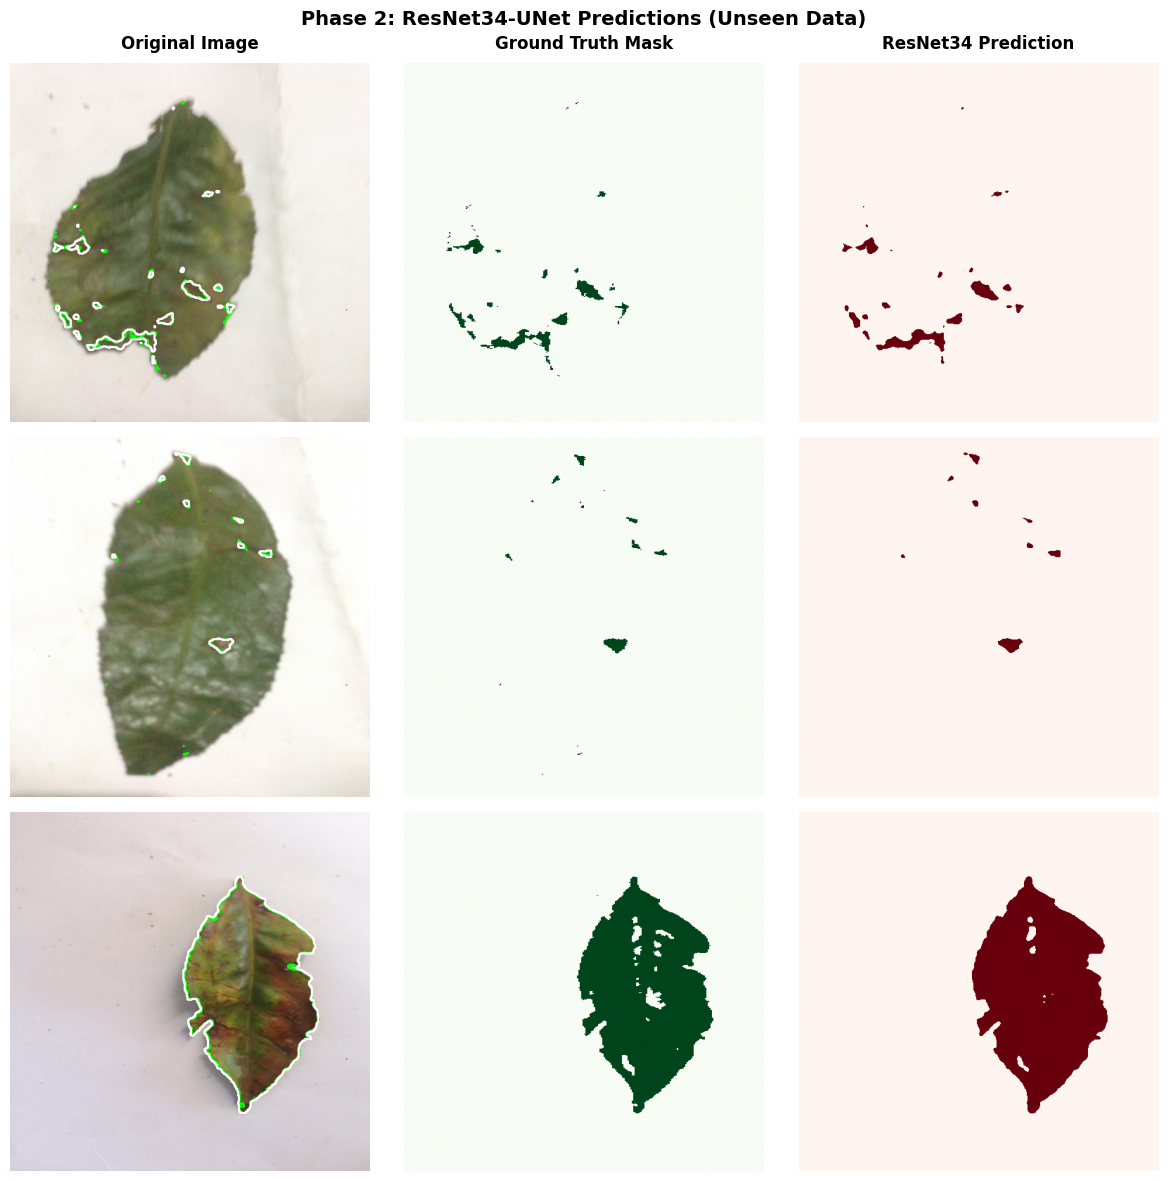

In [13]:
print("📸 Generating ResNet34-UNet Transfer Learning Predictions...")
ckpt_2 = torch.load("resnet34_unet_best.pth", map_location=DEVICE)
model_tl.load_state_dict(ckpt_2["model_state_dict"])
model_tl.eval()

# Reusing the exact same 'images' and 'masks' to compare models directly
with torch.no_grad():
    logits_tl = model_tl(images)
    pred_masks_tl = (torch.sigmoid(logits_tl) >= 0.5).float()

fig, axes = plt.subplots(N_SAMPLES, 3, figsize=(12, 4 * N_SAMPLES))
fig.suptitle("Phase 2: ResNet34-UNet Predictions (Unseen Data)", fontsize=14, fontweight="bold")
col_titles = ["Original Image", "Ground Truth Mask", "ResNet34 Prediction"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=12, fontweight="bold", pad=10)

for row in range(N_SAMPLES):
    orig_img = denorm(images[row].cpu())
    gt_mask = masks[row, 0].cpu().numpy()
    pred_mask = pred_masks_tl[row, 0].cpu().numpy()

    overlay = orig_img.copy()
    contours_gt, _ = cv2.findContours((gt_mask*255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours_pred, _ = cv2.findContours((pred_mask*255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours_gt, -1, (0, 255, 0), 2)
    cv2.drawContours(overlay, contours_pred, -1, (255, 80, 80), 2)

    axes[row, 0].imshow(overlay)
    axes[row, 0].axis("off")
    axes[row, 1].imshow(gt_mask, cmap="Greens", vmin=0, vmax=1)
    axes[row, 1].axis("off")
    axes[row, 2].imshow(pred_mask, cmap="Reds", vmin=0, vmax=1)
    axes[row, 2].axis("off")

plt.tight_layout()
plt.savefig("pred_resnet34.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 8 · Phase 3: EfficientNet-B3 + SCSE (State-of-the-Art)

In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# PHASE 3: EfficientNet-B3 + SCSE Attention (State-of-the-Art)
# ══════════════════════════════════════════════════════════════════════════════
import segmentation_models_pytorch as smp

print("🧠 Phase 3: EfficientNet-B3 + SCSE (SOTA Architecture)")

# ── Model Architecture ────────────────────────────────────────────────────────
model_final = smp.Unet(
    encoder_name="efficientnet-b3",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    decoder_attention_type="scse"  # Squeeze-and-Excitation attention
).to(DEVICE)

# ── Hyper-parameters ──────────────────────────────────────────────────────────
NUM_EPOCHS_FINAL = 100
LR_FINAL = 3e-4
WEIGHT_DECAY_FINAL = 1e-5
GRAD_CLIP_NORM_FINAL = 1.0
CHECKPOINT_PATH_FINAL = "efficientnet_scse_best.pth"

# ── Advanced Loss (Focal Tversky + BCE) ───────────────────────────────────────
criterion_final = FocalTverskyBCELoss(device=DEVICE).to(DEVICE)

optimizer_final = torch.optim.AdamW(model_final.parameters(), lr=LR_FINAL, weight_decay=WEIGHT_DECAY_FINAL)
scheduler_final = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_final, mode='max', factor=0.5, patience=4
)

# ── Train ─────────────────────────────────────────────────────────────────────
history_final = train_evaluate_model(
    model=model_final,
    criterion=criterion_final,
    optimizer=optimizer_final,
    scheduler=scheduler_final,
    num_epochs=NUM_EPOCHS_FINAL,
    train_loader=train_loader,
    val_loader=val_loader,
    checkpoint_path=CHECKPOINT_PATH_FINAL,
    device=DEVICE,
    grad_clip_norm=GRAD_CLIP_NORM_FINAL,
    model_name="EfficientNet-B3 + SCSE (SOTA)"
)

🧠 Phase 3: EfficientNet-B3 + SCSE (SOTA Architecture)


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]


🚀 Training EfficientNet-B3 + SCSE (SOTA)...
 Epoch   TrainLoss    ValLoss   ValDice    ValIoU        LR    Time
----------------------------------------------------------------------
     1      0.7555     0.6378    0.5857    0.4192  3.00e-04   16.5s ✓
     2      0.5683     0.4881    0.6324    0.4679  3.00e-04   14.9s ✓
     3      0.4898     0.4531    0.6207    0.4554  3.00e-04   16.1s
     4      0.4396     0.4052    0.6389    0.4737  3.00e-04   16.8s ✓
     5      0.4037     0.3822    0.6274    0.4620  3.00e-04   15.8s
     6      0.3877     0.3474    0.6522    0.4887  3.00e-04   16.2s ✓
     7      0.3647     0.3590    0.6435    0.4805  3.00e-04   15.9s
     8      0.3844     0.3474    0.6636    0.5004  3.00e-04   16.4s ✓
     9      0.3463     0.3260    0.7422    0.5936  3.00e-04   15.4s ✓
    10      0.3170     0.3102    0.6681    0.5045  3.00e-04   14.8s
    11      0.3171     0.3312    0.7135    0.5601  3.00e-04   15.9s
    12      0.3235     0.3553    0.7394    0.5908  3.00e

### Phase 3 Training Curves


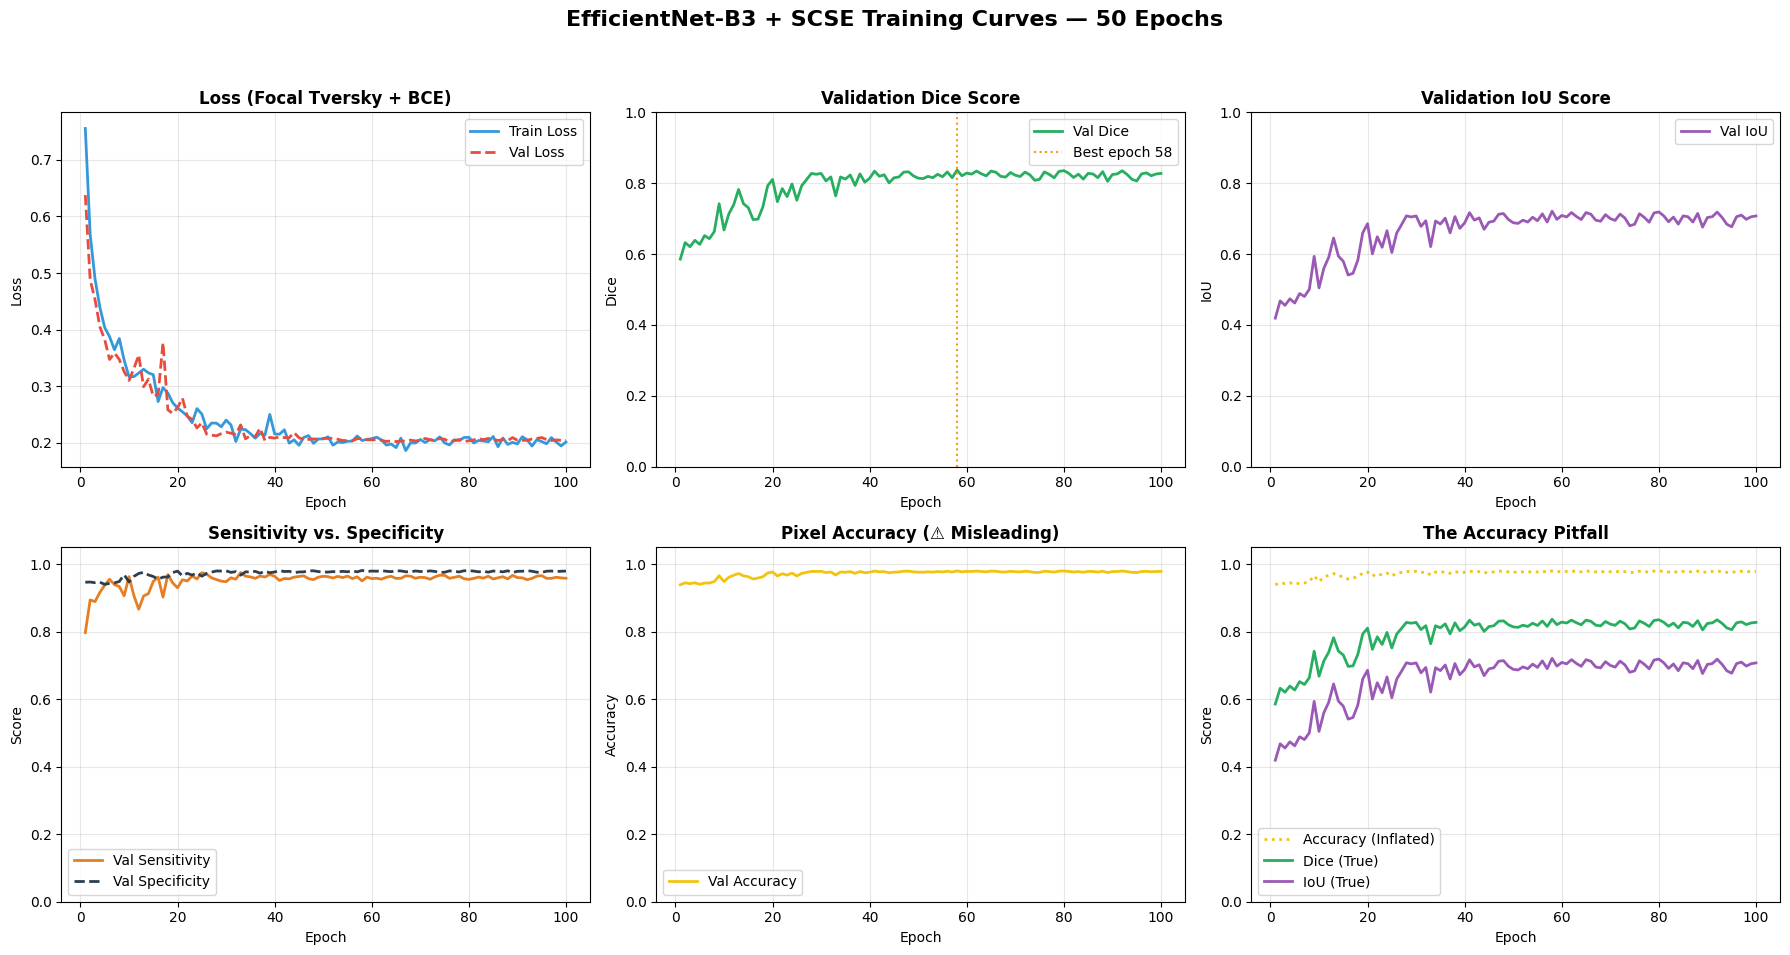

✅ Saved → phase3_training_curves.png


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Use the Final architecture history dictionary
epochs_range_final = range(1, len(history_final["train_loss"]) + 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("EfficientNet-B3 + SCSE Training Curves — 50 Epochs", fontsize=16, fontweight="bold")

# Train vs Val Loss (Updated title for Focal Tversky)
axes[0, 0].plot(epochs_range_final, history_final["train_loss"], label="Train Loss", color="#3498db", linewidth=2)
axes[0, 0].plot(epochs_range_final, history_final["val_loss"], label="Val Loss", color="#e74c3c", linewidth=2, linestyle="--")
axes[0, 0].set_title("Loss (Focal Tversky + BCE)", fontweight="bold")
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# Validation Dice
axes[0, 1].plot(epochs_range_final, history_final["val_dice"], label="Val Dice", color="#27ae60", linewidth=2)
best_dice_ep_final = int(np.argmax(history_final["val_dice"])) + 1
axes[0, 1].axvline(x=best_dice_ep_final, color="#f39c12", linestyle=":", linewidth=1.5, label=f"Best epoch {best_dice_ep_final}")
axes[0, 1].set_title("Validation Dice Score", fontweight="bold")
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Dice")
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3); axes[0, 1].set_ylim(0, 1)

# Validation IoU
axes[0, 2].plot(epochs_range_final, history_final["val_iou"], label="Val IoU", color="#9b59b6", linewidth=2)
axes[0, 2].set_title("Validation IoU Score", fontweight="bold")
axes[0, 2].set_xlabel("Epoch"); axes[0, 2].set_ylabel("IoU")
axes[0, 2].legend(); axes[0, 2].grid(alpha=0.3); axes[0, 2].set_ylim(0, 1)

# Sensitivity vs Specificity
axes[1, 0].plot(epochs_range_final, history_final["val_sensitivity"], label="Val Sensitivity", color="#e67e22", linewidth=2)
axes[1, 0].plot(epochs_range_final, history_final["val_specificity"], label="Val Specificity", color="#2c3e50", linewidth=2, linestyle="--")
axes[1, 0].set_title("Sensitivity vs. Specificity", fontweight="bold")
axes[1, 0].set_xlabel("Epoch"); axes[1, 0].set_ylabel("Score")
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3); axes[1, 0].set_ylim(0, 1.05)

# Pixel Accuracy
axes[1, 1].plot(epochs_range_final, history_final["val_accuracy"], label="Val Accuracy", color="#f1c40f", linewidth=2)
axes[1, 1].set_title("Pixel Accuracy (⚠ Misleading)", fontweight="bold")
axes[1, 1].set_xlabel("Epoch"); axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3); axes[1, 1].set_ylim(0, 1.05)

# Accuracy vs Dice/IoU pitfall
axes[1, 2].plot(epochs_range_final, history_final["val_accuracy"], label="Accuracy (Inflated)", color="#f1c40f", linewidth=2, linestyle=":")
axes[1, 2].plot(epochs_range_final, history_final["val_dice"], label="Dice (True)", color="#27ae60", linewidth=2)
axes[1, 2].plot(epochs_range_final, history_final["val_iou"], label="IoU (True)", color="#9b59b6", linewidth=2)
axes[1, 2].set_title("The Accuracy Pitfall", fontweight="bold")
axes[1, 2].set_xlabel("Epoch"); axes[1, 2].set_ylabel("Score")
axes[1, 2].legend(); axes[1, 2].grid(alpha=0.3); axes[1, 2].set_ylim(0, 1.05)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("phase3_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → phase3_training_curves.png")

### ── Phase 3: EfficientNet-B3 + SCSE Predictions ──

📸 Generating EfficientNet-B3 + SCSE Predictions...


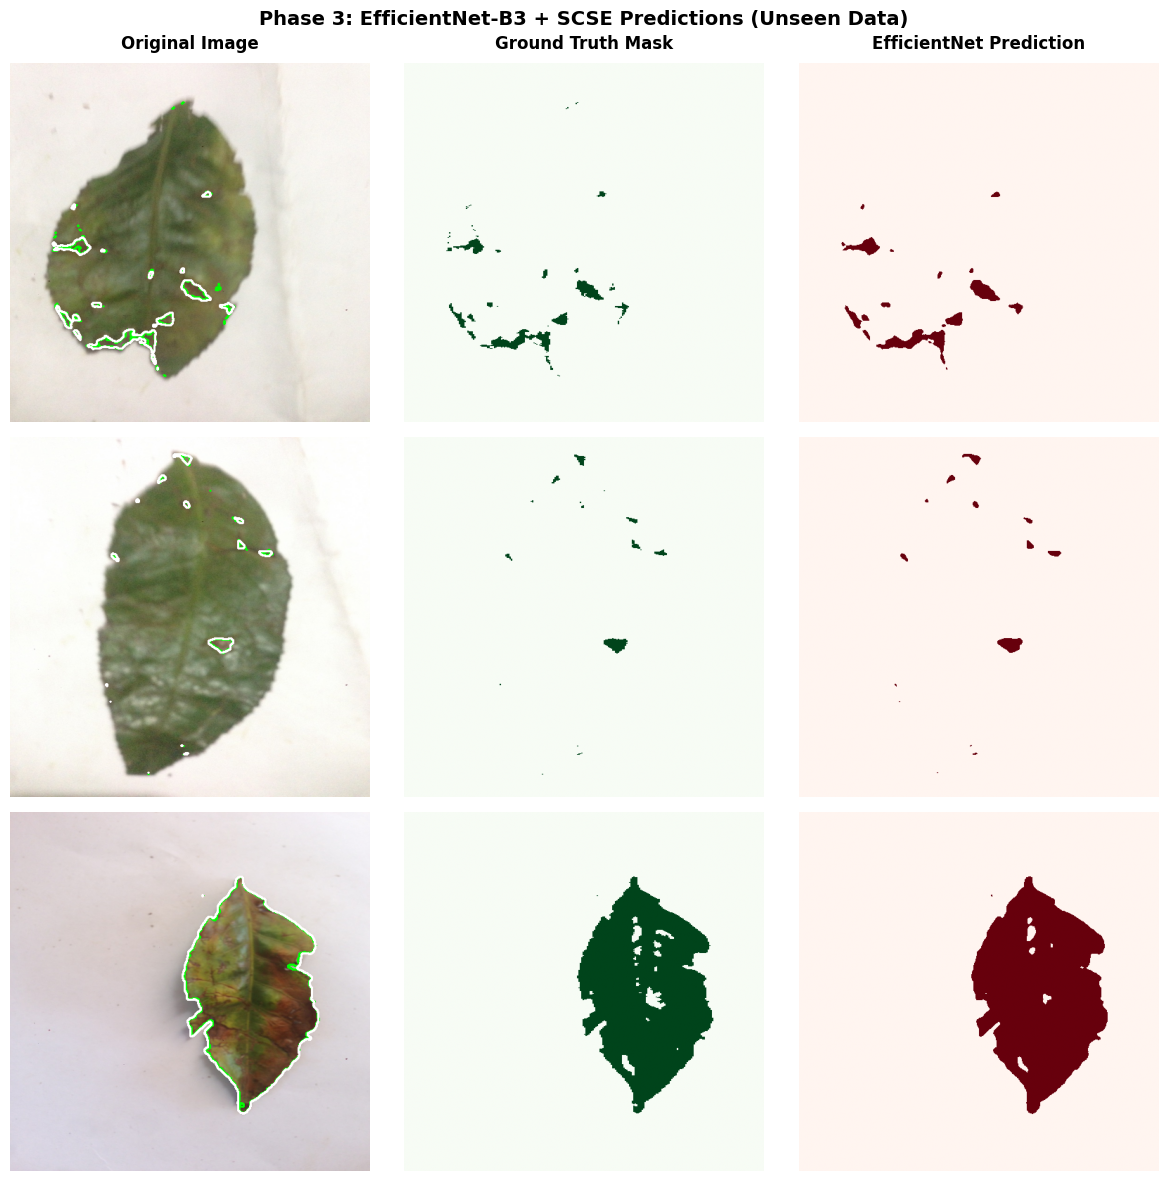

In [16]:
print("📸 Generating EfficientNet-B3 + SCSE Predictions...")
ckpt_3 = torch.load("efficientnet_scse_best.pth", map_location=DEVICE)
model_final.load_state_dict(ckpt_3["model_state_dict"])
model_final.eval()

# Reusing the exact same 'images' and 'masks' to compare models directly
with torch.no_grad():
    logits_final = model_final(images)
    pred_masks_final = (torch.sigmoid(logits_final) >= 0.5).float()

fig, axes = plt.subplots(N_SAMPLES, 3, figsize=(12, 4 * N_SAMPLES))
fig.suptitle("Phase 3: EfficientNet-B3 + SCSE Predictions (Unseen Data)", fontsize=14, fontweight="bold")
col_titles = ["Original Image", "Ground Truth Mask", "EfficientNet Prediction"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=12, fontweight="bold", pad=10)

for row in range(N_SAMPLES):
    orig_img = denorm(images[row].cpu())
    gt_mask = masks[row, 0].cpu().numpy()
    pred_mask = pred_masks_final[row, 0].cpu().numpy()

    overlay = orig_img.copy()
    contours_gt, _ = cv2.findContours((gt_mask*255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours_pred, _ = cv2.findContours((pred_mask*255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours_gt, -1, (0, 255, 0), 2)
    cv2.drawContours(overlay, contours_pred, -1, (255, 80, 80), 2)

    axes[row, 0].imshow(overlay)
    axes[row, 0].axis("off")
    axes[row, 1].imshow(gt_mask, cmap="Greens", vmin=0, vmax=1)
    axes[row, 1].axis("off")
    axes[row, 2].imshow(pred_mask, cmap="Reds", vmin=0, vmax=1)
    axes[row, 2].axis("off")

plt.tight_layout()
plt.savefig("pred_efficientnet.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 9 · Comparative Analysis (Ablation Study)

Compares all 3 architectures on the **unseen test set**.

In [17]:
print("🧪 Running Comparative Test Set Evaluation (All 3 Models)...")

# ══════════════════════════════════════════════════════════════════════════════
# 1. Load all three checkpoints
# ══════════════════════════════════════════════════════════════════════════════
import segmentation_models_pytorch as smp

model_seaunet = model  # Already in memory
model_resnet34 = smp.Unet(
    encoder_name="resnet34", encoder_weights=None,
    in_channels=3, classes=1, decoder_attention_type=None
).to(DEVICE)
model_effnet = smp.Unet(
    encoder_name="efficientnet-b3", encoder_weights=None,
    in_channels=3, classes=1, decoder_attention_type="scse"
).to(DEVICE)

ckpt_sea = torch.load("sea_unet_binary_best.pth", map_location=DEVICE)
ckpt_res = torch.load("resnet34_unet_best.pth", map_location=DEVICE)
ckpt_eff = torch.load("efficientnet_scse_best.pth", map_location=DEVICE)

model_seaunet.load_state_dict(ckpt_sea["model_state_dict"])
model_resnet34.load_state_dict(ckpt_res["model_state_dict"])
model_effnet.load_state_dict(ckpt_eff["model_state_dict"])

# ══════════════════════════════════════════════════════════════════════════════
# 2. Evaluate each model on the test set
# ══════════════════════════════════════════════════════════════════════════════
models = {
    "SEA-UNet (Baseline)": model_seaunet,
    "ResNet34-UNet (TL)": model_resnet34,
    "EfficientNet-B3 (SOTA)": model_effnet,
}

test_results = {}

for name, mdl in models.items():
    mdl.eval()
    tracker = MetricsTracker()

    with torch.no_grad():
        for batch in test_loader:
            images = batch["image"].to(DEVICE, non_blocking=True)
            masks  = batch["mask"].to(DEVICE, non_blocking=True)
            logits = mdl(images)

            loss_fn = TrueBinaryLoss(dice_weight=0.7, pos_weight=torch.tensor([15.0]).to(DEVICE))
            total_loss, _, _ = loss_fn(logits, masks)
            tracker.update(loss=total_loss.item(), pred=logits, target=masks)

    test_results[name] = tracker.epoch_summary()
    print(f"✅ {name} evaluated.")

# ══════════════════════════════════════════════════════════════════════════════
# 3. Print Comparative Report
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("🏆 OFFICIAL COMPARATIVE TEST SET RESULTS (BSc Capstone Report-Ready)")
print("="*80)
print(f"{'Model':<28} {'Dice':>8} {'IoU':>8} {'Sens':>8} {'Spec':>8} {'Acc':>8} {'Loss':>8}")
print("-"*80)

for name, metrics in test_results.items():
    print(f"{name:<28} {metrics['dice']:>8.4f} {metrics['iou']:>8.4f} "
          f"{metrics['sensitivity']:>8.4f} {metrics['specificity']:>8.4f} "
          f"{metrics['accuracy']:>8.4f} {metrics['loss']:>8.4f}")

print("="*80)
best_dice_model = max(test_results, key=lambda x: test_results[x]['dice'])
print(f"📊 Best Dice Score: {best_dice_model} ({test_results[best_dice_model]['dice']:.4f})")
print("="*80)

🧪 Running Comparative Test Set Evaluation (All 3 Models)...
✅ SEA-UNet (Baseline) evaluated.
✅ ResNet34-UNet (TL) evaluated.
✅ EfficientNet-B3 (SOTA) evaluated.

🏆 OFFICIAL COMPARATIVE TEST SET RESULTS (BSc Capstone Report-Ready)
Model                            Dice      IoU     Sens     Spec      Acc     Loss
--------------------------------------------------------------------------------
SEA-UNet (Baseline)            0.7536   0.6097   0.8493   0.9770   0.9711   0.3279
ResNet34-UNet (TL)             0.7741   0.6352   0.8726   0.9791   0.9742   0.2942
EfficientNet-B3 (SOTA)         0.7845   0.6511   0.9129   0.9784   0.9753   0.2577
📊 Best Dice Score: EfficientNet-B3 (SOTA) (0.7845)


📈 Generating Comparative Training Curves (All 3 Models)...
✅ Saved → comparative_analysis_ablation.png


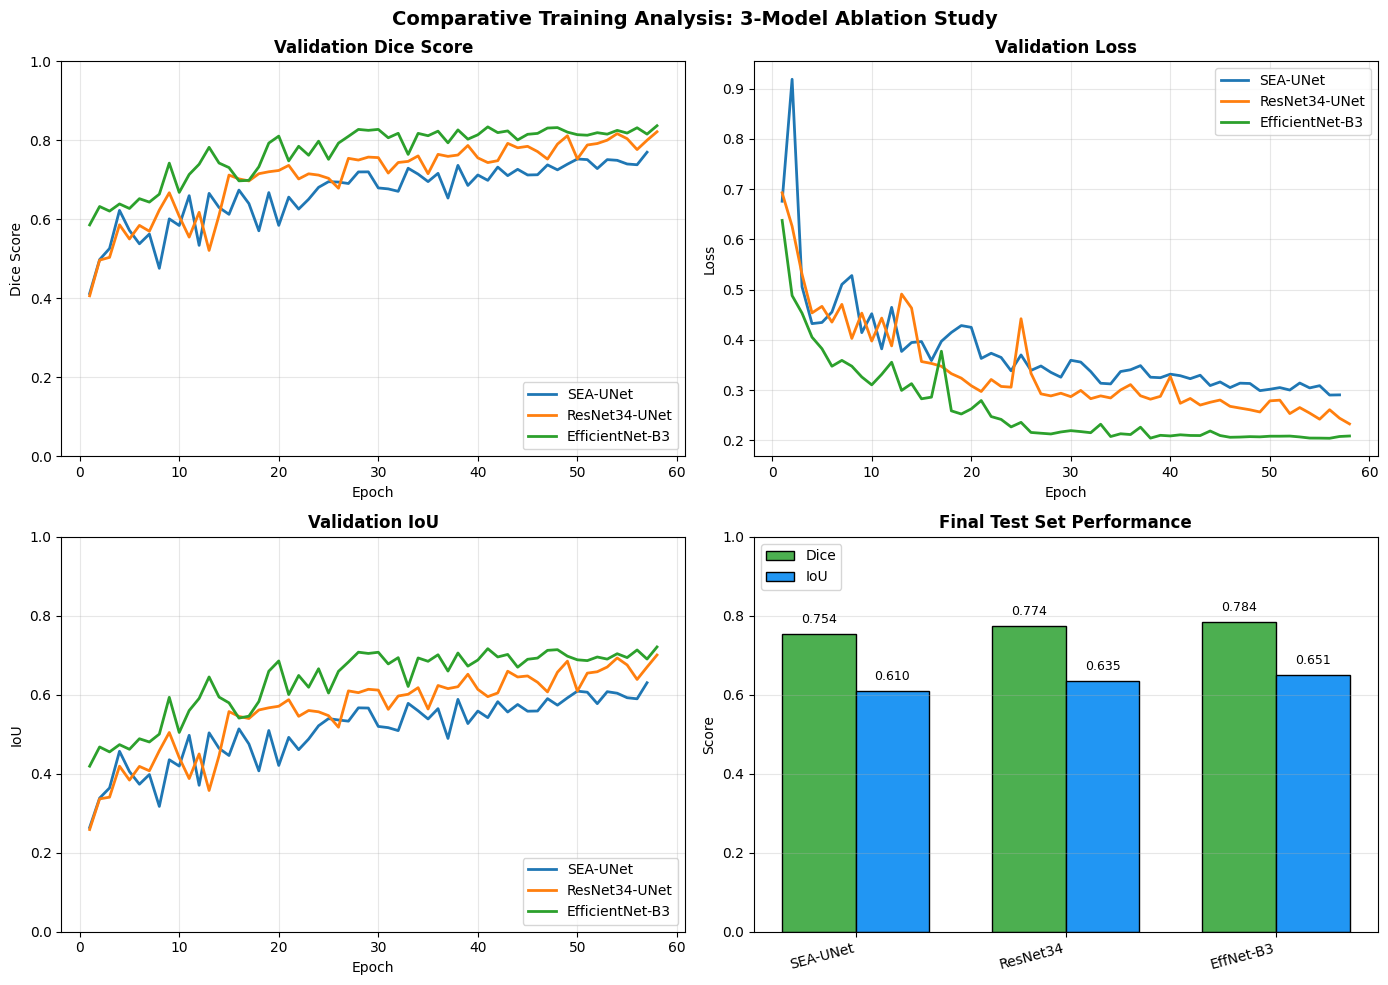

In [18]:
import matplotlib.pyplot as plt
import numpy as np

print("📈 Generating Comparative Training Curves (All 3 Models)...")

hist_sea = ckpt_sea.get("history", history)
hist_res = ckpt_res.get("history", history_tl)
hist_eff = ckpt_eff.get("history", history_final)

epochs_sea = range(1, len(hist_sea["val_dice"]) + 1)
epochs_res = range(1, len(hist_res["val_dice"]) + 1)
epochs_eff = range(1, len(hist_eff["val_dice"]) + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Comparative Training Analysis: 3-Model Ablation Study", fontsize=14, fontweight='bold')

colors = {'sea': '#1f77b4', 'res': '#ff7f0e', 'eff': '#2ca02c'}
labels = {'sea': 'SEA-UNet', 'res': 'ResNet34-UNet', 'eff': 'EfficientNet-B3'}

# Plot 1: Validation Dice
ax1 = axes[0, 0]
ax1.plot(epochs_sea, hist_sea["val_dice"], color=colors['sea'], label=labels['sea'], linewidth=2)
ax1.plot(epochs_res, hist_res["val_dice"], color=colors['res'], label=labels['res'], linewidth=2)
ax1.plot(epochs_eff, hist_eff["val_dice"], color=colors['eff'], label=labels['eff'], linewidth=2)
ax1.set_title("Validation Dice Score", fontweight='bold')
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Dice Score")
ax1.legend(loc='lower right'); ax1.grid(True, alpha=0.3); ax1.set_ylim([0, 1])

# Plot 2: Validation Loss
ax2 = axes[0, 1]
ax2.plot(epochs_sea, hist_sea["val_loss"], color=colors['sea'], label=labels['sea'], linewidth=2)
ax2.plot(epochs_res, hist_res["val_loss"], color=colors['res'], label=labels['res'], linewidth=2)
ax2.plot(epochs_eff, hist_eff["val_loss"], color=colors['eff'], label=labels['eff'], linewidth=2)
ax2.set_title("Validation Loss", fontweight='bold')
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.legend(loc='upper right'); ax2.grid(True, alpha=0.3)

# Plot 3: Validation IoU
ax3 = axes[1, 0]
ax3.plot(epochs_sea, hist_sea["val_iou"], color=colors['sea'], label=labels['sea'], linewidth=2)
ax3.plot(epochs_res, hist_res["val_iou"], color=colors['res'], label=labels['res'], linewidth=2)
ax3.plot(epochs_eff, hist_eff["val_iou"], color=colors['eff'], label=labels['eff'], linewidth=2)
ax3.set_title("Validation IoU", fontweight='bold')
ax3.set_xlabel("Epoch"); ax3.set_ylabel("IoU")
ax3.legend(loc='lower right'); ax3.grid(True, alpha=0.3); ax3.set_ylim([0, 1])

# Plot 4: Test Set Bar Chart
ax4 = axes[1, 1]
model_names = list(test_results.keys())
dice_scores = [test_results[m]['dice'] for m in model_names]
iou_scores = [test_results[m]['iou'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35
bars1 = ax4.bar(x - width/2, dice_scores, width, label='Dice', color='#4CAF50', edgecolor='black')
bars2 = ax4.bar(x + width/2, iou_scores, width, label='IoU', color='#2196F3', edgecolor='black')
ax4.set_title("Final Test Set Performance", fontweight='bold')
ax4.set_ylabel("Score"); ax4.set_xticks(x)
ax4.set_xticklabels(['SEA-UNet', 'ResNet34', 'EffNet-B3'], rotation=15, ha='right')
ax4.legend(loc='upper left'); ax4.set_ylim([0, 1]); ax4.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("comparative_analysis_ablation.png", dpi=300, bbox_inches='tight')
print("✅ Saved → comparative_analysis_ablation.png")
plt.show()

---
## 10 · Model Export & Download

In [19]:
print("⬇️ Downloading All Three Model Checkpoints...")

from google.colab import files
import os

checkpoints = [
    "sea_unet_binary_best.pth",
    "resnet34_unet_best.pth",
    "efficientnet_scse_best.pth",
]

print("\n📦 Model Checkpoints:")
print("-" * 50)

for ckpt in checkpoints:
    if os.path.exists(ckpt):
        size_mb = os.path.getsize(ckpt) / (1024 * 1024)
        print(f"  ✅ {ckpt:<30} ({size_mb:.1f} MB)")
    else:
        print(f"  ❌ {ckpt:<30} (NOT FOUND)")

print("-" * 50)

print("\n⬇️ Initiating downloads...")
for ckpt in checkpoints:
    if os.path.exists(ckpt):
        try:
            files.download(ckpt)
            print(f"   Downloaded: {ckpt}")
        except Exception as e:
            print(f"   ⚠️ Failed: {ckpt} - {e}")

print("""
╔══════════════════════════════════════════════════════════════════════════╗
║  ALL 3 MODELS DOWNLOADED - DEPLOYMENT INSTRUCTIONS                       ║
╠══════════════════════════════════════════════════════════════════════════╣
║  1. Rename .pth → .pt files for FastAPI backend                          ║
║  2. Move to backend/checkpoints/ directory                               ║
║  3. Update backend/api/main.py to select the best model                  ║
║                                                                          ║
║  Recommended for Production: efficientnet_scse_best.pt (highest Dice)    ║
╚══════════════════════════════════════════════════════════════════════════╝
""")

⬇️ Downloading All Three Model Checkpoints...

📦 Model Checkpoints:
--------------------------------------------------
  ✅ sea_unet_binary_best.pth       (378.0 MB)
  ✅ resnet34_unet_best.pth         (279.9 MB)
  ✅ efficientnet_scse_best.pth     (147.7 MB)
--------------------------------------------------

⬇️ Initiating downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   Downloaded: sea_unet_binary_best.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   Downloaded: resnet34_unet_best.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   Downloaded: efficientnet_scse_best.pth

╔══════════════════════════════════════════════════════════════════════════╗
║  ALL 3 MODELS DOWNLOADED - DEPLOYMENT INSTRUCTIONS                       ║
╠══════════════════════════════════════════════════════════════════════════╣
║  1. Rename .pth → .pt files for FastAPI backend                          ║
║  2. Move to backend/checkpoints/ directory                               ║
║  3. Update backend/api/main.py to select the best model                  ║
║                                                                          ║
║  Recommended for Production: efficientnet_scse_best.pt (highest Dice)    ║
╚══════════════════════════════════════════════════════════════════════════╝



---
## 11 · Two-Stage Pipeline: Segmentation + Classification

**Problem**: Binary segmentation models only detect WHERE disease is, not WHAT disease it is.

**Solution**: Two-stage inference pipeline:
1. **Stage 1 — Segmentation**: EfficientNet-B3+SCSE localizes diseased regions  
2. **Stage 2 — Classification**: ResNet-50 identifies the disease type

```
┌───────────────────────────────────────────────────────────────────────────┐
│                        TeaVision AI Pipeline                              │
├───────────────────────────────────────────────────────────────────────────┤
│                                                                           │
│   Input Image ────► Segmentation Model ────► Disease Mask (Binary)       │
│        │                (U-Net)                    │                      │
│        │                                           │                      │
│        ▼                                           ▼                      │
│   Classification Model ◄─────────────────── Severity %                   │
│     (ResNet-50)                              (pixels affected)            │
│        │                                                                  │
│        ▼                                                                  │
│   Disease Class ────► Agent Pipeline ────► Treatment Recommendation      │
│   (8 classes)           (LangGraph)          (ChromaDB + Ollama)         │
│                                                                           │
└───────────────────────────────────────────────────────────────────────────┘
```

### 11.1 · Classifier Architecture

The classifier is a pre-trained ResNet-50 with a custom FC head:
- **Encoder**: ResNet-50 (pretrained on ImageNet, ~23M params)
- **FC Head**: `Dropout(0.5) → Linear(2048 → 8)`
- **Input**: 224×224 RGB images
- **Output**: 8 logits (one per disease class)

### 11.2 · Inference Logic

```python
# Stage 1: Segmentation
mask, severity_pct = segmentation_model(image)

# Stage 2: Classification (only if disease detected)
if severity_pct >= 5.0:
    disease_class = classification_model(image)
else:
    disease_class = "healthy"
```

The classifier checkpoint is saved as: `tea_leaves_disease_classification_ResNet_model.pth`

In [20]:
import shutil
from google.colab import files

source_folder = '/content/mask_cache'
zip_filename = '/content/tea_leaf_masks_cache'

print(f"📦 Zipping all masks in {source_folder}...")
shutil.make_archive(zip_filename, 'zip', source_folder)
print(f"✅ Zipping complete! File saved to: {zip_filename}.zip")
print("⬇️ Initiating download...")
files.download(zip_filename + '.zip')

📦 Zipping all masks in /content/mask_cache...
✅ Zipping complete! File saved to: /content/tea_leaf_masks_cache.zip
⬇️ Initiating download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
# Uncomment to delete corrupted masks
# !rm -rf /content/mask_cache/*
# print("Corrupted masks deleted!")